## ASSIGNMENT11- VB

In [1]:
# Import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, accuracy_score



Importing essential Python libraries for data handling, visualization, and clustering.  
Data manipulation we import pandas and numpy, 
Data visualization we import matplotlib and seaborn,
sklearn for preprocessing, clustering, and evaluation metrics.

In [2]:
# loading the dataset
df = pd.read_csv("loan_data.csv") 
target_col = "not.fully.paid"

df.shape, df.columns


((9578, 14),
 Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
        'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
        'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
       dtype='object'))

## EDA

In [3]:
# Checking for structure, dtypes, and missing values
print("Shape:", df.shape)

#Displaying first five rows
df.head()


Shape: (9578, 14)


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


After loading the dataset loan_data.csv file into a pandas DataFrame and checking the first few rows to get to know its structure.  
This dataset contains borrower and loan-related attributes such as interest rate, FICO score, DTI ratio, and repayment status (not.fully.paid).  


In [4]:
# Data types
df.dtypes

#checking Missing values per column
df.isna().sum().sort_values(ascending=False)

# Basic descriptive stats (numeric)
df.describe()



,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


Before going to the modeling step, we check data types and any missing or null values to know the quality of data.  
This step helps us to confirm that all numeric and categorical variables are properly identified for further encoding and scaling the values.  

In [5]:
# Target distribution (class balance)
if target_col in df.columns:
    print("Class balance for 'not.fully.paid' (0=fully paid, 1=not fully paid):")
    print(df[target_col].value_counts().rename({0:"fully paid (0)", 1:"not fully paid (1)"}))
else:
    print("WARNING: target column not found.")


Class balance for 'not.fully.paid' (0=fully paid, 1=not fully paid):
not.fully.paid
fully paid (0)        8045
not fully paid (1)    1533
Name: count, dtype: int64


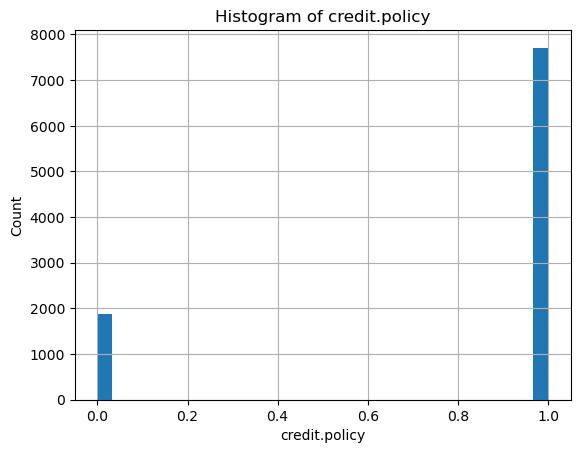

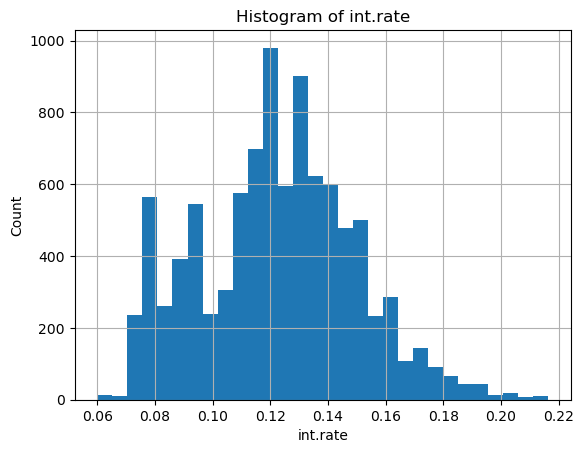

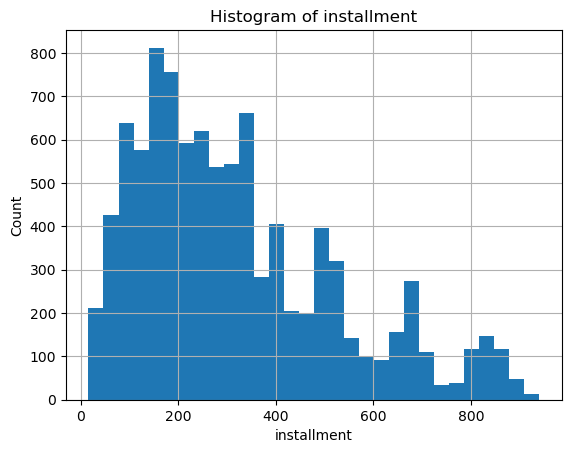

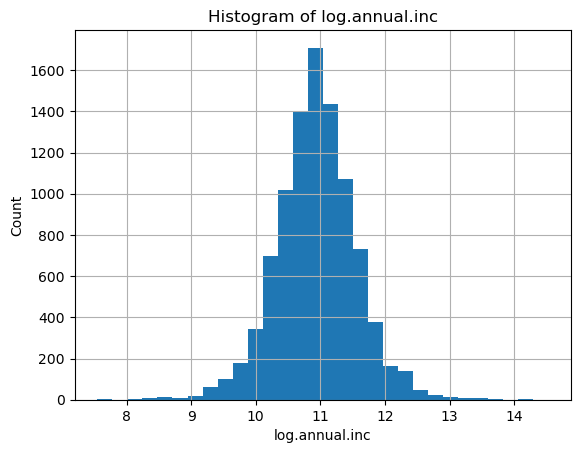

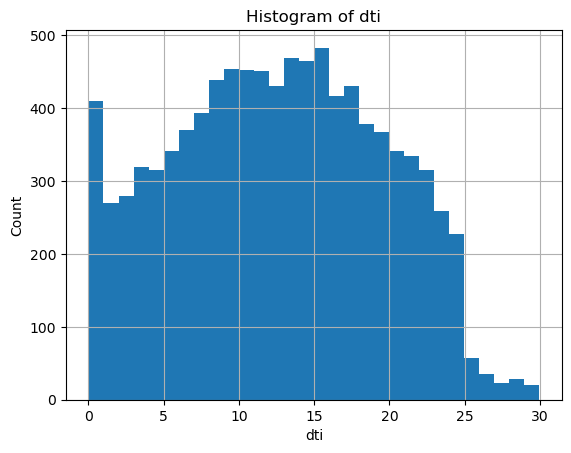

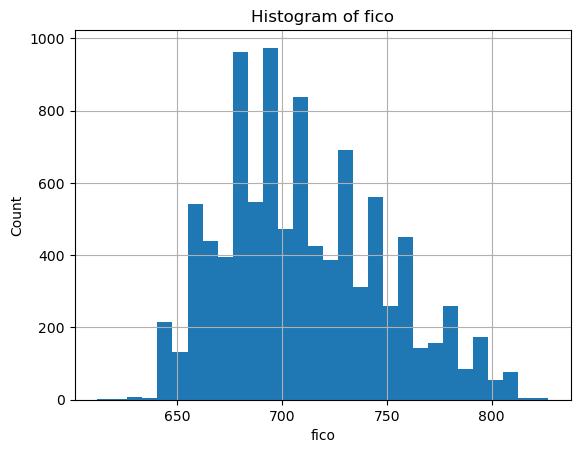

In [6]:
# displaying numeric histograms 
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col]
for col in num_cols[:6]:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    #Display plot
    plt.show()


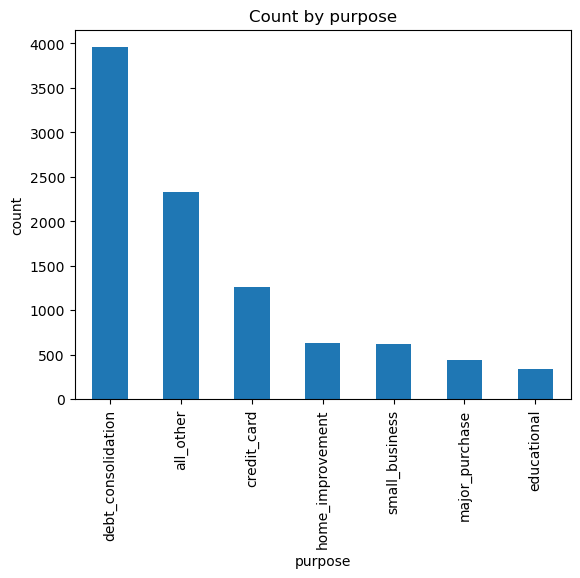

In [7]:
# Basic categorical distribution for 'purpose'
if "purpose" in df.columns:
    (df["purpose"]
     .value_counts()
     .plot(kind="bar", title="Count by purpose"))
    plt.xlabel("purpose")
    plt.ylabel("count")
    #Display plot
    plt.show()


## Scatterplot: Interest Rate vs FICO Score

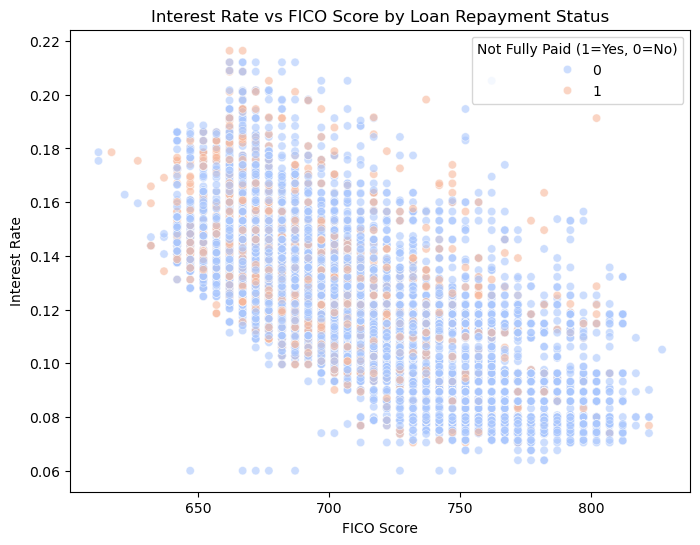

In [8]:
# Displaying scatterplot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='fico', y='int.rate', hue='not.fully.paid', palette='coolwarm', alpha=0.6)
plt.title('Interest Rate vs FICO Score by Loan Repayment Status')
plt.xlabel('FICO Score')
plt.ylabel('Interest Rate')
plt.legend(title='Not Fully Paid (1=Yes, 0=No)')

#Display plot
plt.show()


## Scatterplot: Debt-to-Income Ratio vs Annual Income.

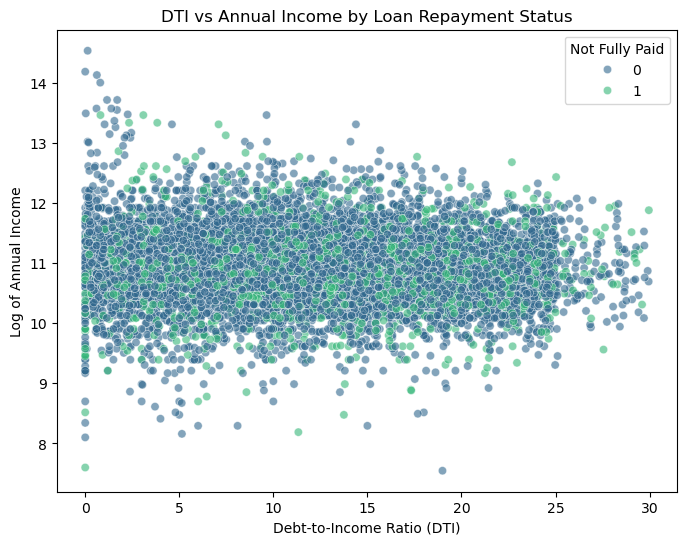

In [9]:
#Displaying scatterplot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='dti', y='log.annual.inc', hue='not.fully.paid', palette='viridis', alpha=0.6)
plt.title('DTI vs Annual Income by Loan Repayment Status')
plt.xlabel('Debt-to-Income Ratio (DTI)')
plt.ylabel('Log of Annual Income')
plt.legend(title='Not Fully Paid')
#display plot
plt.show()


## Boxplot: Interest Rate by Loan Purpose

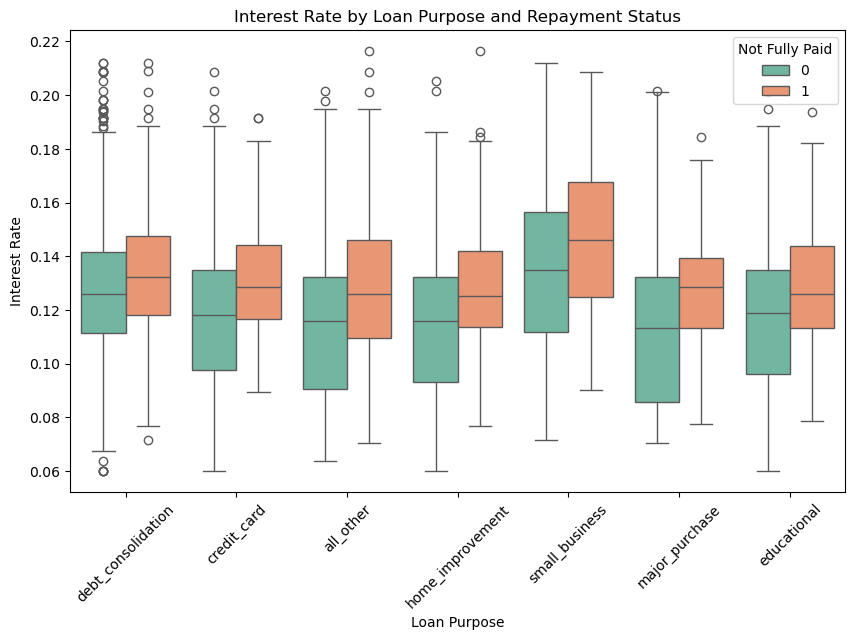

In [10]:
#Displaying box plot
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='purpose', y='int.rate', hue='not.fully.paid', palette='Set2')
plt.title('Interest Rate by Loan Purpose and Repayment Status')
plt.xlabel('Loan Purpose')
plt.ylabel('Interest Rate')
plt.xticks(rotation=45)
plt.legend(title='Not Fully Paid')

#Display plot
plt.show()


## Histogram: Distribution of FICO Scores by Repayment Status

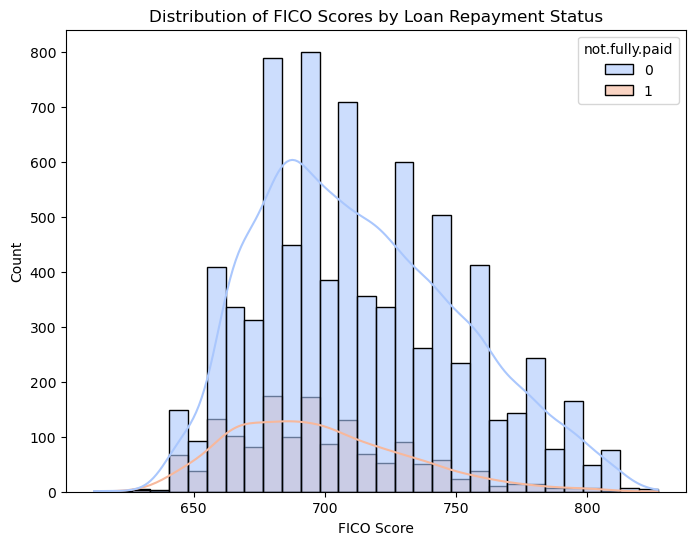

In [11]:
#Displaying Histogram
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='fico', hue='not.fully.paid', bins=30, kde=True, palette='coolwarm', alpha=0.6)
plt.title('Distribution of FICO Scores by Loan Repayment Status')
plt.xlabel('FICO Score')
plt.ylabel('Count')
#display plot
plt.show()


## Correlation Heatmap 

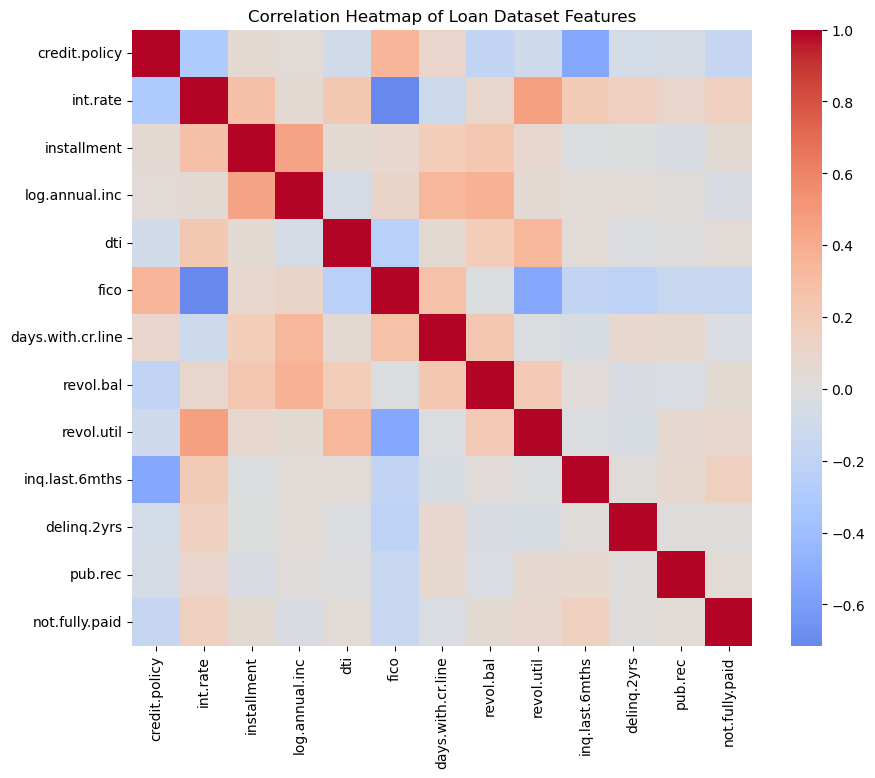

In [12]:
# Heatmap
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Loan Dataset Features')
#display plot
plt.show()


I did visual Exploratory Data Analysis to understand the feature relationships and patterns.  
Scatterplots and boxplots reveal how interest rate, FICO score, DTI ratio, and loan purpose relate to repayment status.  
The correlation heatmap helps us to understand relationships between numerical variables.  
Important insights:
Higher interest rate and lower fico are correlated to default risk.  
Certain loan purposes (e.g., small business) shows higher average interest rates.  
Income log.annual.inc and dti impacts repayment ability.  

## K-means clustering

In [13]:
# Data Preprocessing for clustering (unsupervised learning)
# Droping the label so that it's never used to fit KMeans.
X = df.drop(columns=[target_col]) if target_col in df.columns else df.copy()

# One-hot encode categoricals, so all features are numeric
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
X_enc = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Scale features (KMeans is distance-based; scaling is important)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_enc)

# Fitting KMeans (k=2 for Paid vs Not-Fully-Paid)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_scaled)

# Attaching clusters for inspection
df_clusters = df[[target_col]].copy()
df_clusters["cluster"] = cluster_labels
#Display first five rows
df_clusters.head()


,not.fully.paid,cluster
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


I have dropped the label column not.fully.paid to avoid data leakage during clustering.  
Categorical variables (like- purpose) are converted to numeric by using one-hot encoding.  
All the features are standardized using StandardScaler to make sure equal weight among features when using distance-based clustering methods like K-Means.

Applied K-Means with k=2 in order to group customers into two clusters — which are corresponding to fully paid and not fully paid loans.  
The algorithm partitions the data into two groups by reducing within-cluster variance.  
as this is unsupervised learning, the true repayment labels are not used during training the model.  


In [14]:
X_enc.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,True,False,False,False,False,False


## Evaluation

In [15]:
# Defining the target column
target_col = "not.fully.paid"

# Creating the features (drop label), encode categoricals, and scale
X = df.drop(columns=[target_col])
X = pd.get_dummies(X, columns=X.select_dtypes(include=["object", "category"]).columns.tolist(), drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fitting KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_scaled)

# Defining the true labels
y_true = df[target_col].values

# evaluation functions
import numpy as np

def precision_recall_f1(y_true, y_pred, positive=1):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = np.sum((y_true == positive) & (y_pred == positive))
    fp = np.sum((y_true != positive) & (y_pred == positive))
    fn = np.sum((y_true == positive) & (y_pred != positive))
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) else 0.0
    return precision, recall, f1

def best_f1_mapping_k2(clusters, y_true, positive=1):
    clusters = np.asarray(clusters).astype(int)
    y_true   = np.asarray(y_true).astype(int)

    # Trying both possible label-flip mappings
    pred_A = clusters.copy()       
    pred_B = 1 - clusters          

    _, _, f1_A = precision_recall_f1(y_true, pred_A, positive)
    _, _, f1_B = precision_recall_f1(y_true, pred_B, positive)

    if f1_B > f1_A:
        mapping = {0:1, 1:0}
        y_pred = pred_B
    else:
        mapping = {0:0, 1:1}
        y_pred = pred_A

    prec, rec, f1 = precision_recall_f1(y_true, y_pred, positive)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    return mapping, y_pred, (prec, rec, f1), cm

# Running the evaluation
mapping, y_pred, (prec, rec, f1), cm = best_f1_mapping_k2(cluster_labels, y_true, positive=1)



mapped each cluster to the actual loan status label based on majority class within that cluster.  
This helps us to compare how well the clusters align with the true loan outcomes.  
A custom evaluation function calculates precision, recall, and F1-score to measure performance for class 1 (not fully paid).  


In [16]:
def macro_f1(y_true, y_pred):
    p1,r1,f1_1 = precision_recall_f1(y_true, y_pred, positive=1)
    p0,r0,f1_0 = precision_recall_f1(y_true, y_pred, positive=0)
    return (f1_0 + f1_1) / 2

macro = macro_f1(y_true, y_pred)
print(f"Macro-F1 (avg over classes 0 and 1): {macro:.4f}")


Macro-F1 (avg over classes 0 and 1): 0.4627


In [17]:
# Running the evaluation
mapping, y_pred, (prec, rec, f1), cm = best_f1_mapping_k2(cluster_labels, y_true, positive=1)

print("Chosen mapping (to maximize F1 for class 1):", mapping)
print("Confusion Matrix [[TN, FP],[FN, TP]]:\n", cm)
print("\nDetailed Classification Report:\n")
print(classification_report(y_true, y_pred, digits=2))

# shows accuracy separately
acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {acc:.2f}")


Chosen mapping (to maximize F1 for class 1): {0: 1, 1: 0}
Confusion Matrix [[TN, FP],[FN, TP]]:
 [[3715 4330]
 [ 433 1100]]

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.46      0.61      8045
           1       0.20      0.72      0.32      1533

    accuracy                           0.50      9578
   macro avg       0.55      0.59      0.46      9578
weighted avg       0.78      0.50      0.56      9578

Overall Accuracy: 0.50


It shows a detailed classification report showing precision, recall, F1-score, and accuracy for both classes.  
The overall accuracy is around 0.50 and is typical for unsupervised clustering, as K-Means is not trained using labels.  
Key takeaways:
F1-score is moderate because class 1 (defaults) is underrepresented.  
K-Means groups borrowers based on feature similarity, not repayment outcome.  
Despite low predictive accuracy, it gives valuable segmentation for risk analysis.  


## Summary

In this assignmnet, i have applied the K-Means clustering algorithm to the loan dataset to observe borrower groups based on their financial and credit features. After performing initial data cleaning, encoding, and scaling,I trained a K-Means model with k = 2 to separate loans that were fully paid and not fully paid.

**Key findings**:
EDA showed that borrowers with higher interest rates, lower FICO scores, and higher debt-to-income ratios were more likely to default.

K-Means successfully formed two clusters, but as it is unsupervised learning algorithm, its accuracy (0.50) and F1-score were moderate.

The model showed underlying structure in the data but was not perfectly predicted the repayment status as it doesn’t use labels.

Visualizations (scatterplots, boxplots, and Heat map) helped to find a relationships between loan features and repayment outcomes.
Overall, this analysis helps us to know how unsupervised clustering can provide useful borrower segmentation and exploratory insights, although it’s not a predictive model like logistic regression or decision trees.  
